## **Importing of required Libraries**

In [44]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import ExtraTreesClassifier
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

## **1. Reading and Understanding of the Training Data**

In [2]:
# Importing dataset
dataset = pd.read_csv('adult.csv')

In [3]:
# Preview dataset
dataset.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
# Shape of dataset
print('Rows: {} Columns: {}'.format(dataset.shape[0], dataset.shape[1]))

Rows: 32561 Columns: 15


In [5]:
# Features data-type
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
# Statistical summary
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [7]:
# Check for null values
round((dataset.isnull().sum() / dataset.shape[0]) * 100, 2).astype(str) + ' %'

age               0.0 %
workclass         0.0 %
fnlwgt            0.0 %
education         0.0 %
education.num     0.0 %
marital.status    0.0 %
occupation        0.0 %
relationship      0.0 %
race              0.0 %
sex               0.0 %
capital.gain      0.0 %
capital.loss      0.0 %
hours.per.week    0.0 %
native.country    0.0 %
income            0.0 %
dtype: object

In [8]:
# Check for '?' in dataset
round((dataset.isin(['?']).sum() / dataset.shape[0])
      * 100, 2).astype(str) + ' %'

age                0.0 %
workclass         5.64 %
fnlwgt             0.0 %
education          0.0 %
education.num      0.0 %
marital.status     0.0 %
occupation        5.66 %
relationship       0.0 %
race               0.0 %
sex                0.0 %
capital.gain       0.0 %
capital.loss       0.0 %
hours.per.week     0.0 %
native.country    1.79 %
income             0.0 %
dtype: object

In [9]:
# Checking the counts of label categories
income = dataset['income'].value_counts(normalize=True)
round(income * 100, 2).astype('str') + ' %'

income
<=50K    75.92 %
>50K     24.08 %
Name: proportion, dtype: object

## **2. Visualisation of Data and Data Preprocessing:**

The dataset doesn't have any null values, but it contains missing values in the form of '?' which needs to be preprocessed.

The dataset is unbalanced, as the dependent feature 'income' contains 75.92% values have income less than 50k and 24.08% values have income more than 50k.

In [ ]:
## **2.1: Univariate Analysis**

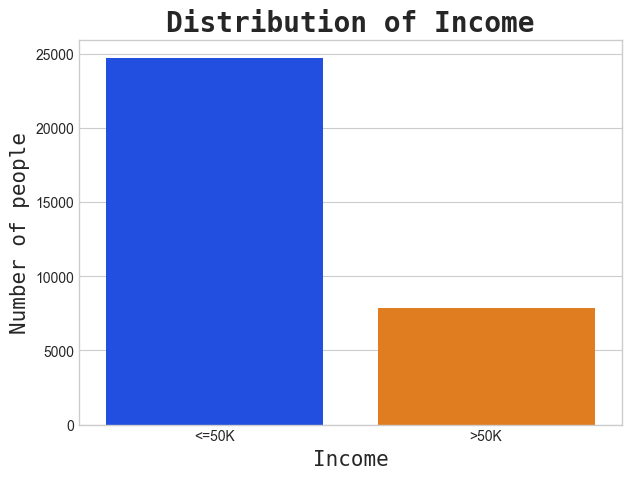

In [13]:
# Creating a barplot for 'Income'
income = dataset['income'].value_counts()

plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(7, 5))

# FIX: Explicitly pass index and values as keyword arguments
sns.barplot(x=income.index, y=income.values, palette='bright')

plt.title('Distribution of Income', fontdict={
          'fontname': 'Monospace', 'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Income', fontdict={'fontname': 'Monospace', 'fontsize': 15})
plt.ylabel('Number of people', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.tick_params(labelsize=10)
plt.show()

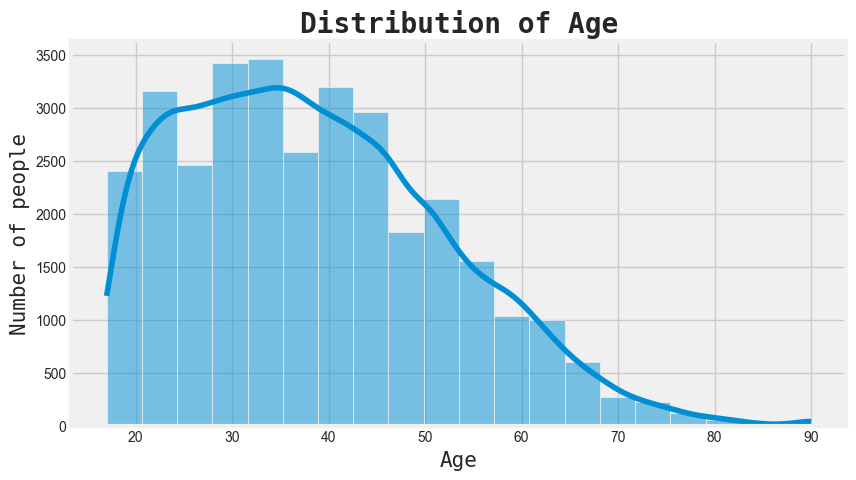

In [14]:
# Creating a distribution plot for 'Age'
age = dataset['age'].value_counts()

plt.figure(figsize=(10, 5))
plt.style.use('fivethirtyeight')

# FIX: Replaced deprecated distplot with histplot and enabled the curve
sns.histplot(data=dataset, x='age', bins=20, kde=True)

plt.title('Distribution of Age', fontdict={
          'fontname': 'Monospace', 'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Age', fontdict={'fontname': 'Monospace', 'fontsize': 15})
plt.ylabel('Number of people', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.tick_params(labelsize=10)
plt.show()

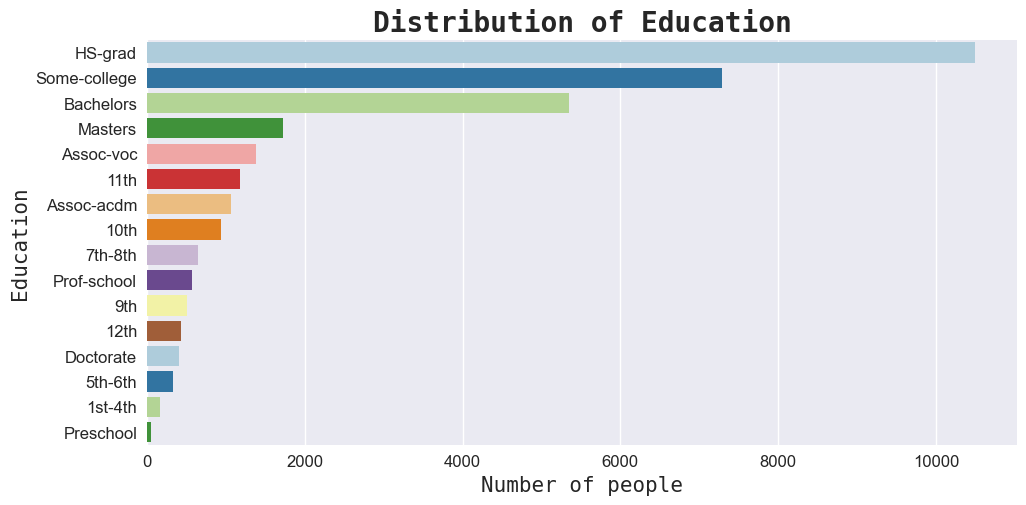

In [15]:
# Creating a barplot for 'Education'
edu = dataset['education'].value_counts()

# FIX 1: Updated to the modern Matplotlib stylesheet alias
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10, 5))

# FIX 2: Added explicit keyword arguments for a horizontal bar plot
sns.barplot(x=edu.values, y=edu.index, palette='Paired')

plt.title('Distribution of Education', fontdict={
          'fontname': 'Monospace', 'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Number of people', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.ylabel('Education', fontdict={'fontname': 'Monospace', 'fontsize': 15})
plt.tick_params(labelsize=12)
plt.show()

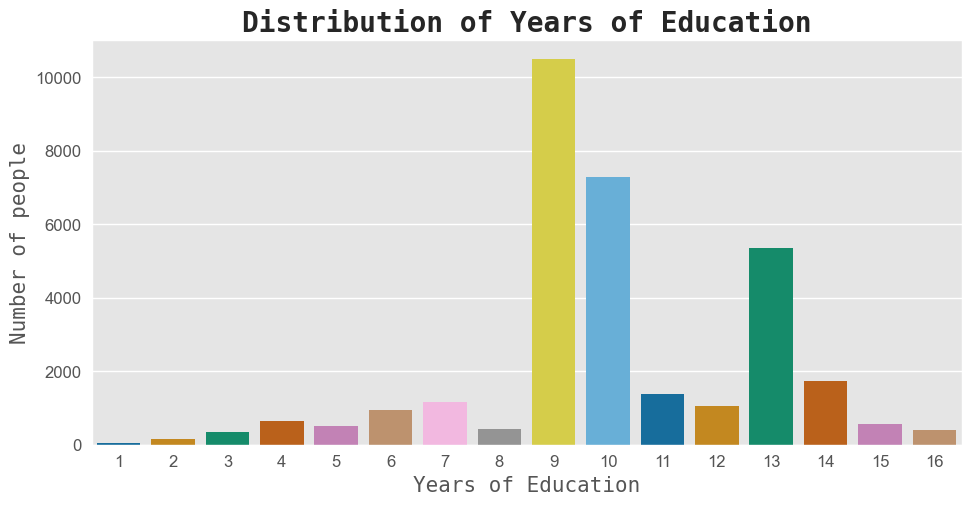

In [16]:
# Creating a barplot for 'Years of Education'
edu_num = dataset['education.num'].value_counts()

plt.style.use('ggplot')
plt.figure(figsize=(10, 5))

# FIX: Explicitly pass index and values as keyword arguments
sns.barplot(x=edu_num.index, y=edu_num.values, palette='colorblind')

plt.title('Distribution of Years of Education', fontdict={
          'fontname': 'Monospace', 'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Years of Education', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.ylabel('Number of people', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.tick_params(labelsize=12)
plt.show()

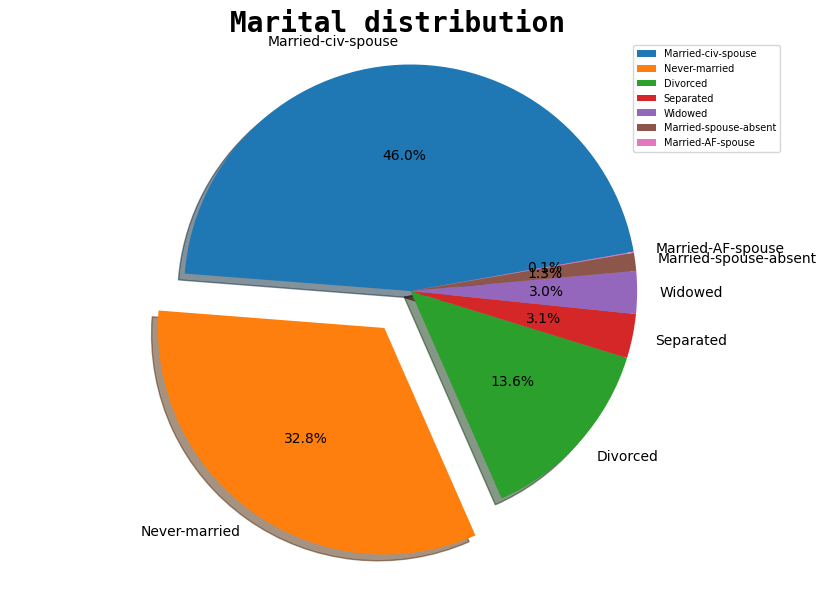

In [17]:
# Creating a pie chart for 'Marital status'
marital = dataset['marital.status'].value_counts()

plt.style.use('default')
plt.figure(figsize=(10, 7))

# FIX: Dynamically generate the explode tuple based on the actual number of unique categories
# It highlights the 2nd largest category (0.2) just like your original code intended
num_categories = len(marital)
explode_list = [0] * num_categories
if num_categories > 1:
    explode_list[1] = 0.20
explode = tuple(explode_list)

# Generate the pie chart safely
plt.pie(marital.values, labels=marital.index, startangle=10, 
        explode=explode, shadow=True, autopct='%1.1f%%')

plt.title('Marital distribution', fontdict={
          'fontname': 'Monospace', 'fontsize': 20, 'fontweight': 'bold'})

# FIX: Consolidated the duplicate legend calls into a single structured call
plt.legend(prop={'size': 7}, loc="best")

plt.axis('equal')
plt.show()

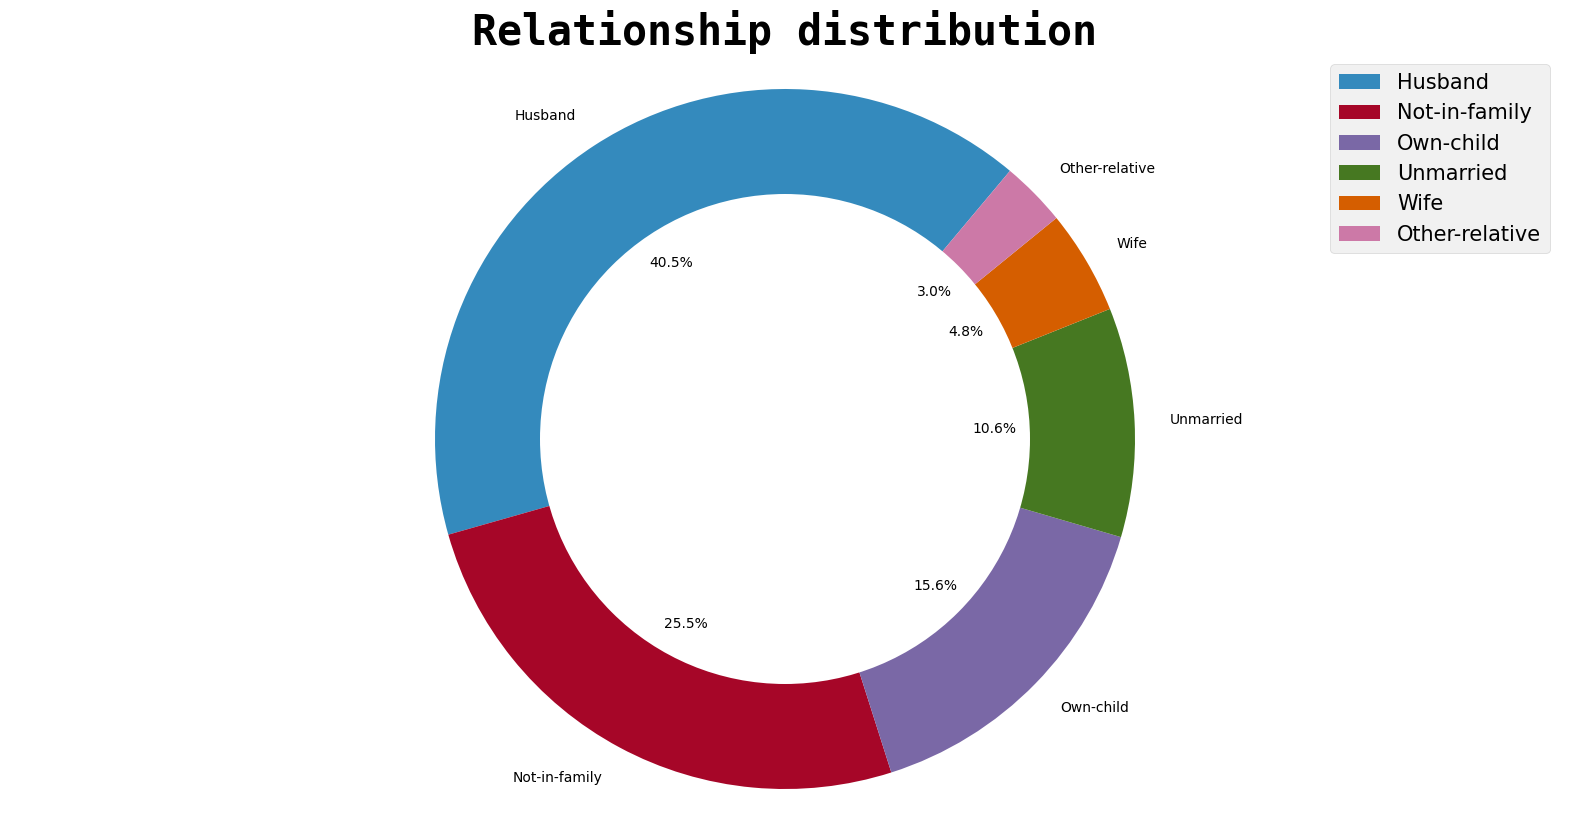

In [18]:
# Creating a donut chart for 'Relationship'
relation = dataset['relationship'].value_counts()

plt.style.use('bmh')
plt.figure(figsize=(20, 10))

# Generate the base pie chart
plt.pie(relation.values, labels=relation.index,
        startangle=50, autopct='%1.1f%%')

# Create the white inner circle to make it a donut chart
centre_circle = plt.Circle((0, 0), 0.7, fc='white')

# FIX: Replaced deprecated fig.gca() with plt.gca() to add the circle artist safely
plt.gca().add_artist(centre_circle)

plt.title('Relationship distribution', fontdict={
          'fontname': 'Monospace', 'fontsize': 30, 'fontweight': 'bold'})
plt.axis('equal')
plt.legend(prop={'size': 15})
plt.show()

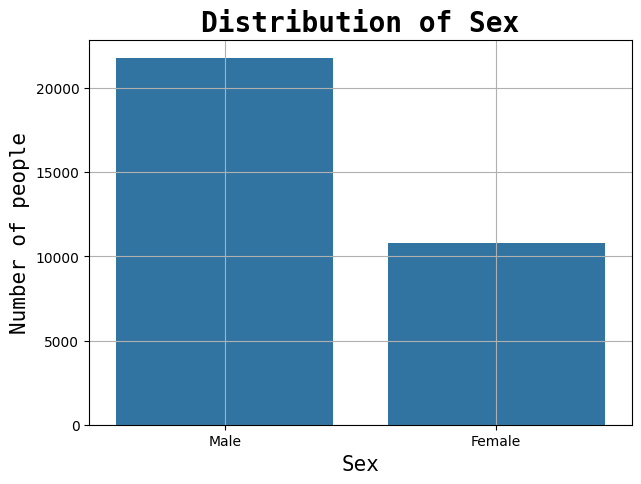

In [19]:
# Creating a barplot for 'Sex'
sex = dataset['sex'].value_counts()

plt.style.use('default')
plt.figure(figsize=(7, 5))

# FIX: Explicitly pass index and values as keyword arguments
sns.barplot(x=sex.index, y=sex.values)

plt.title('Distribution of Sex', fontdict={
          'fontname': 'Monospace', 'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Sex', fontdict={'fontname': 'Monospace', 'fontsize': 15})
plt.ylabel('Number of people', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.tick_params(labelsize=10)
plt.grid()
plt.show()

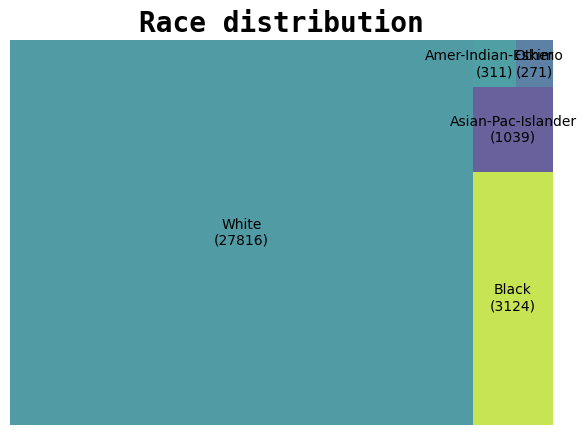

In [22]:
# Creating a Treemap for 'Race'
import squarify
race = dataset['race'].value_counts()

plt.style.use('default')
plt.figure(figsize=(7, 5))

# FIX 1: Format string labels combining the category name and its count 
# This prevents squarify from crashing on modern Matplotlib text rendering engines
labels = [f'{label}\n({val})' for label, val in zip(race.index, race.values)]

# FIX 2: Pass the pre-formatted labels list and remove the raw numeric value parameter
squarify.plot(sizes=race.values, label=labels, alpha=0.8)

plt.title('Race distribution', fontdict={
          'fontname': 'Monospace', 'fontsize': 20, 'fontweight': 'bold'})
plt.axis('off') # Cleaner look for treemaps by removing background graph grids
plt.show()

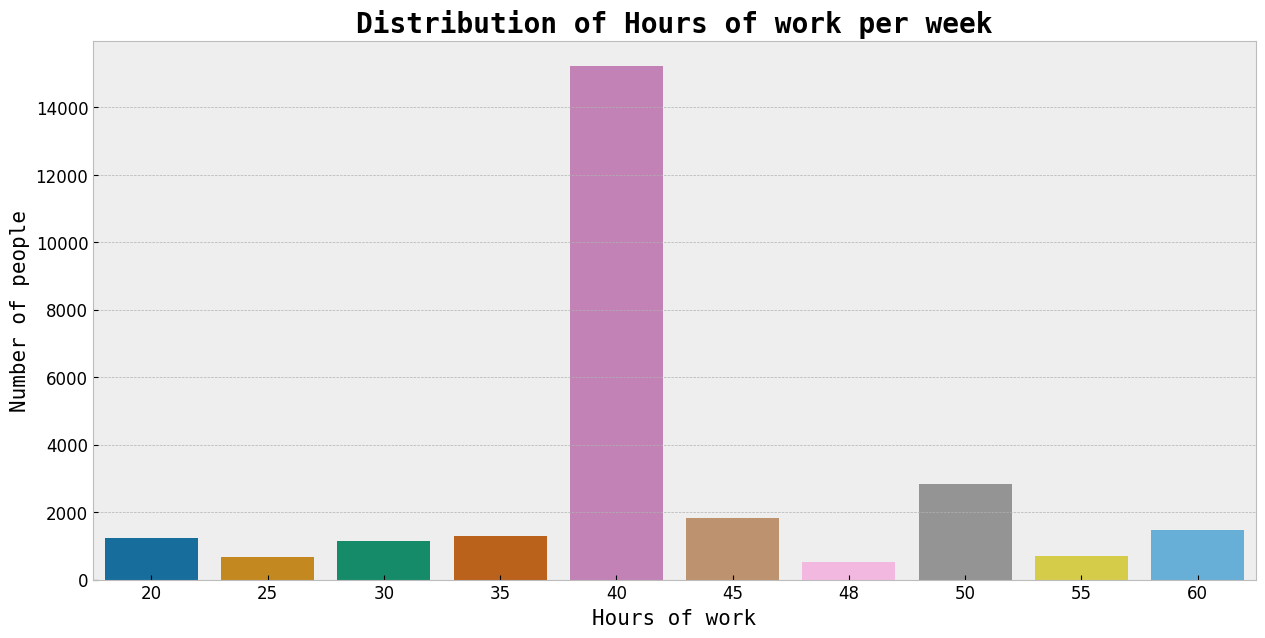

In [24]:
# Creating a barplot for 'Hours per week'
hours = dataset['hours.per.week'].value_counts().head(10)

plt.style.use('bmh')
plt.figure(figsize=(15, 7))

# FIXED: Explicitly defined x and y keyword arguments
sns.barplot(x=hours.index, y=hours.values, palette='colorblind')

plt.title('Distribution of Hours of work per week', fontdict={
          'fontname': 'Monospace', 'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Hours of work', fontdict={'fontname': 'Monospace', 'fontsize': 15})
plt.ylabel('Number of people', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.tick_params(labelsize=12)
plt.show()

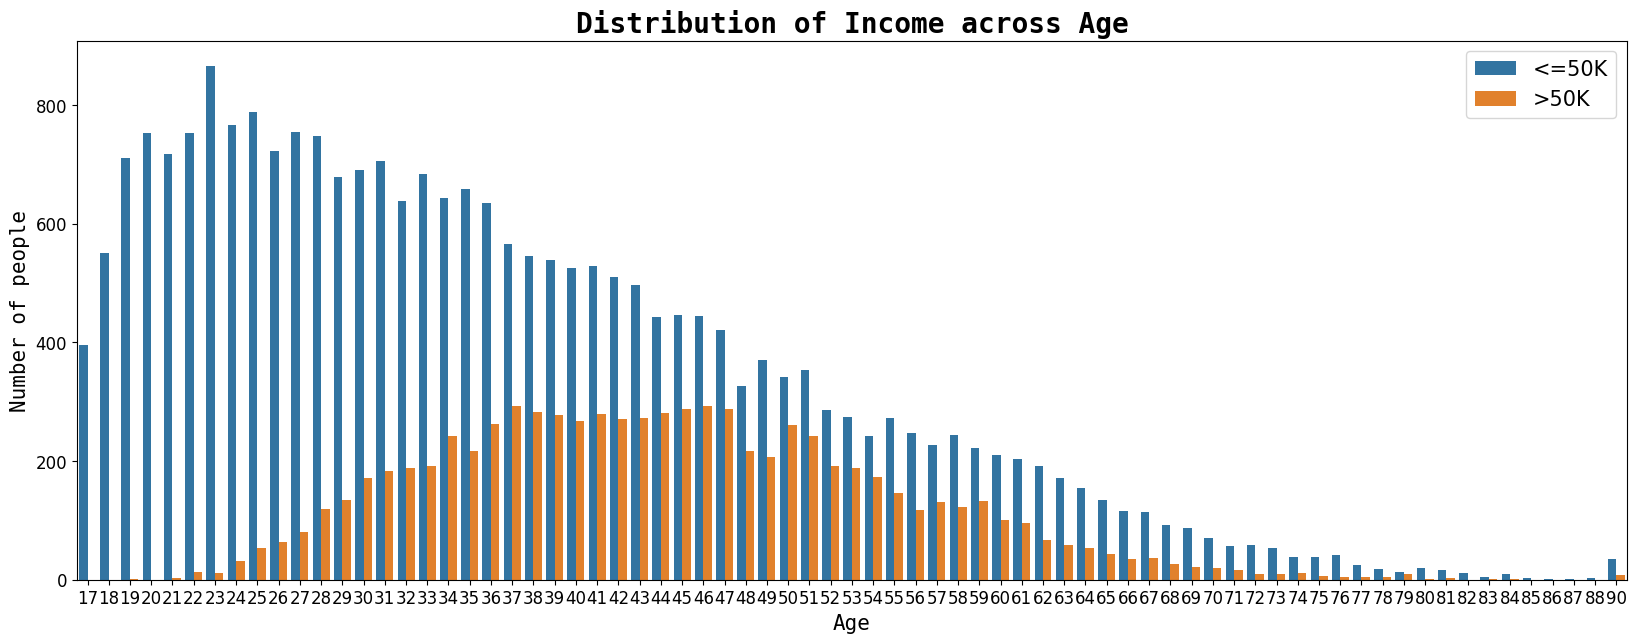

In [25]:
# Creating a countplot of income across age
plt.style.use('default')
plt.figure(figsize=(20, 7))

# FIXED: Used data parameter and explicit x and hue keyword arguments
sns.countplot(data=dataset, x='age', hue='income')

plt.title('Distribution of Income across Age', fontdict={
          'fontname': 'Monospace', 'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Age', fontdict={'fontname': 'Monospace', 'fontsize': 15})
plt.ylabel('Number of people', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.tick_params(labelsize=12)
plt.legend(loc=1, prop={'size': 15})
plt.show()

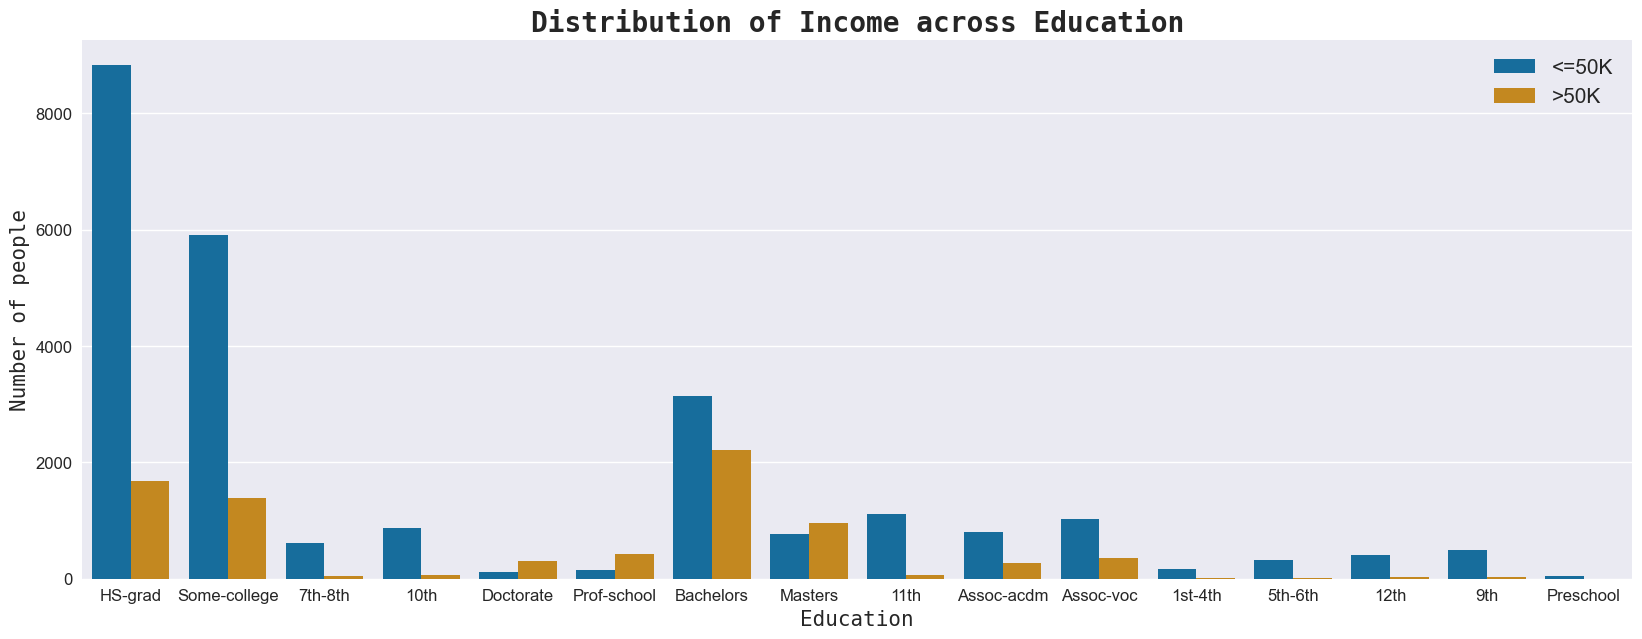

In [26]:
plt.style.use('seaborn-v0_8') 
plt.figure(figsize=(20, 7))

# FIXED: Used data parameter and explicit keyword arguments instead of positional series
sns.countplot(data=dataset, x='education', hue='income', palette='colorblind')

plt.title('Distribution of Income across Education', fontdict={
          'fontname': 'Monospace', 'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Education', fontdict={'fontname': 'Monospace', 'fontsize': 15})
plt.ylabel('Number of people', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.tick_params(labelsize=12)
plt.legend(loc=1, prop={'size': 15})
plt.show()

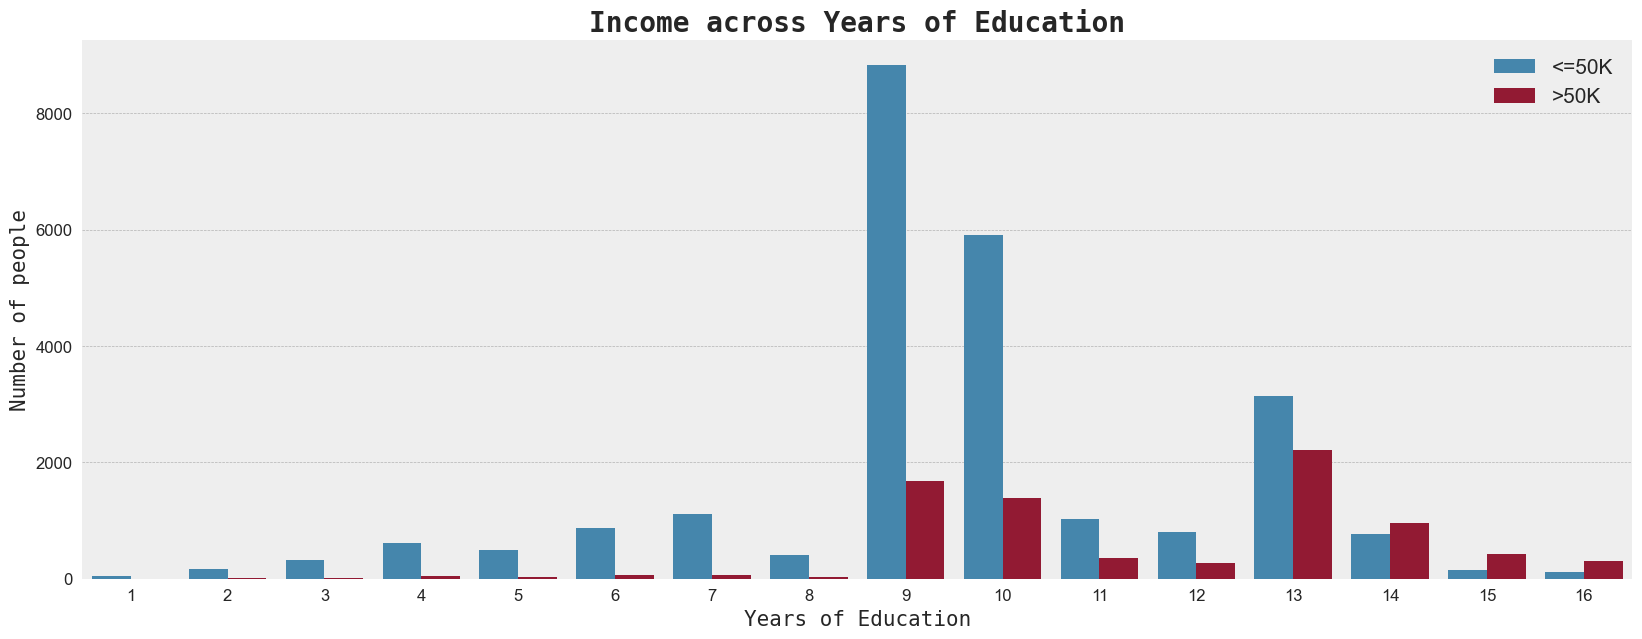

In [27]:
# Creating a countplot of income across years of education
plt.style.use('bmh')
plt.figure(figsize=(20, 7))

# FIXED: Passed the dataset via 'data' and used explicit string columns for x and hue
sns.countplot(data=dataset, x='education.num', hue='income')

plt.title('Income across Years of Education', fontdict={
          'fontname': 'Monospace', 'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Years of Education', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.ylabel('Number of people', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.tick_params(labelsize=12)
plt.legend(loc=1, prop={'size': 15})
plt.savefig('bi2.png')
plt.show()

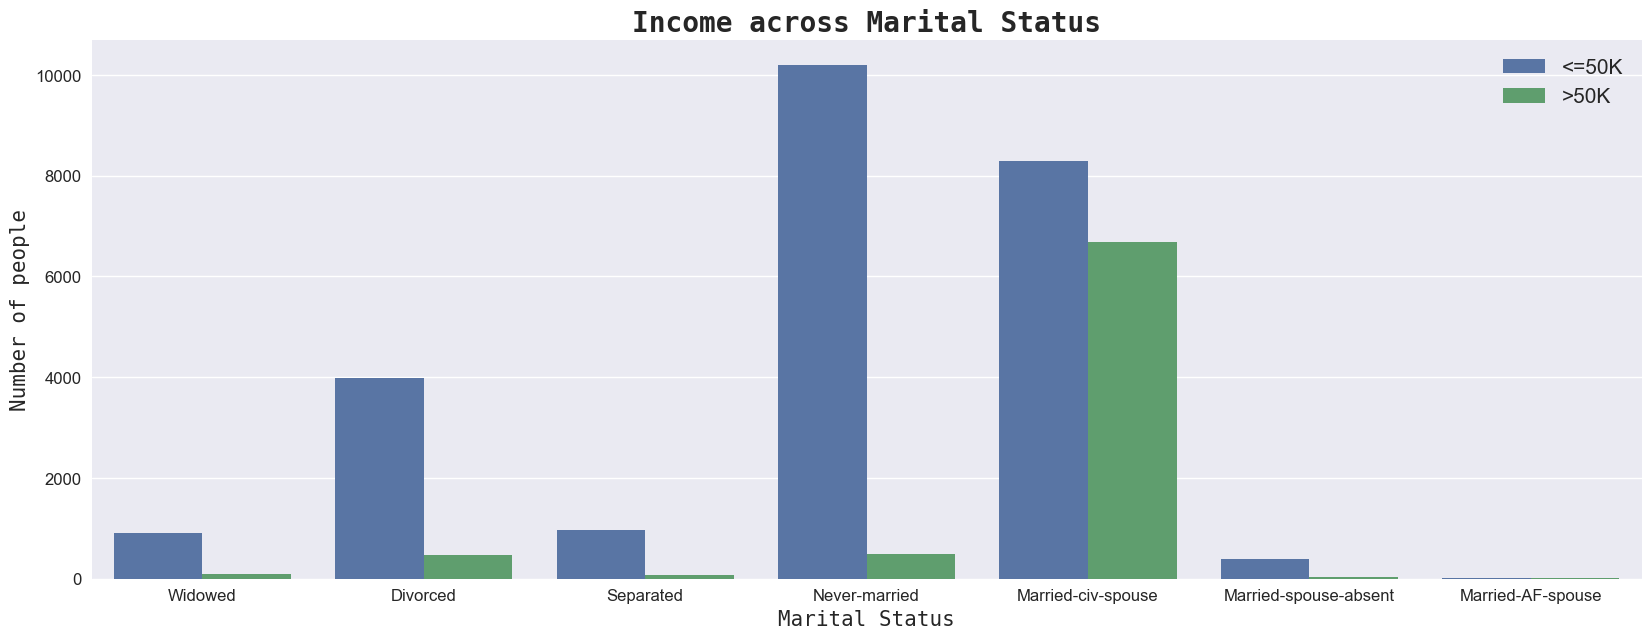

In [28]:
# FIXED: Updated style to prevent crashing on modern Matplotlib
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(20, 7))

# FIXED: Used data parameter and explicit keyword strings for x and hue
sns.countplot(data=dataset, x='marital.status', hue='income')

plt.title('Income across Marital Status', fontdict={
          'fontname': 'Monospace', 'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Marital Status', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.ylabel('Number of people', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.tick_params(labelsize=12)
plt.legend(loc=1, prop={'size': 15})
plt.show()

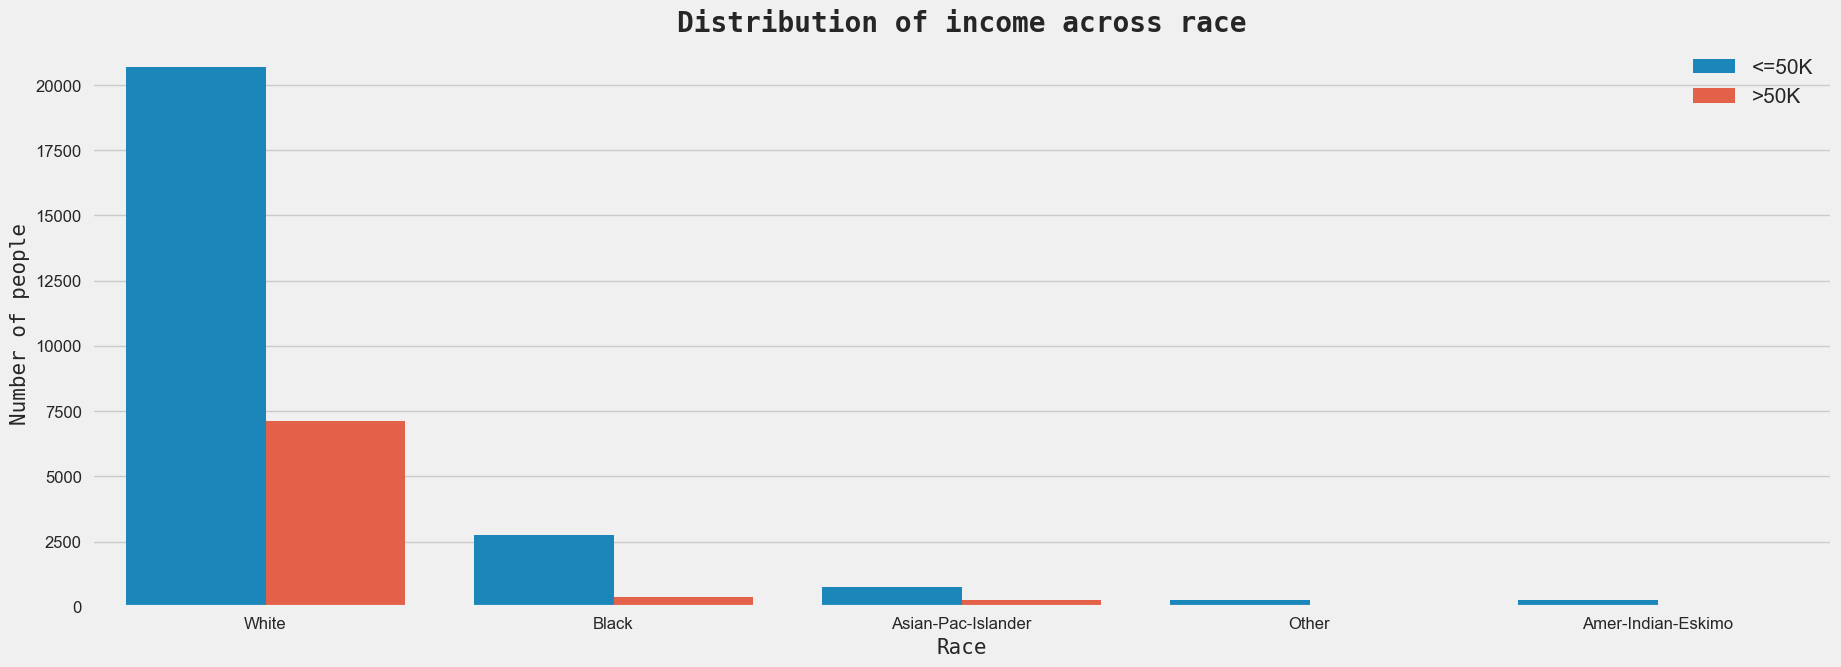

In [29]:
# Creating a countplot of income across race
plt.style.use('fivethirtyeight')
plt.figure(figsize=(20, 7))

# FIXED: Passed the dataset via 'data' and used explicit string columns for x and hue
sns.countplot(data=dataset, x='race', hue='income')

plt.title('Distribution of income across race', fontdict={
          'fontname': 'Monospace', 'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Race', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.ylabel('Number of people', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.tick_params(labelsize=12)
plt.legend(loc=1, prop={'size': 15})
plt.show()

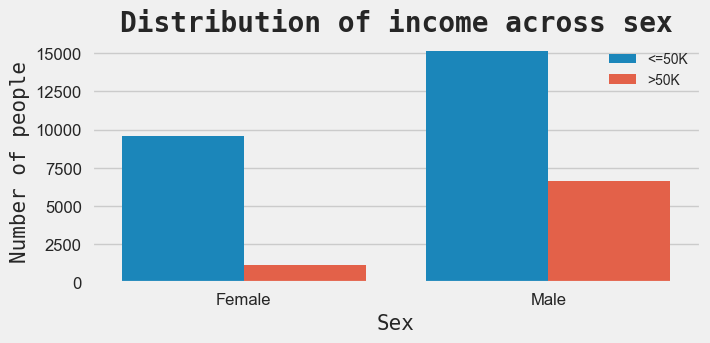

In [30]:
# Creating a countplot of income across sex
plt.style.use('fivethirtyeight')
plt.figure(figsize=(7, 3))

# FIXED: Passed the dataset via 'data' and used explicit string columns for x and hue
sns.countplot(data=dataset, x='sex', hue='income')

plt.title('Distribution of income across sex', fontdict={
          'fontname': 'Monospace', 'fontsize': 20, 'fontweight': 'bold'})
plt.xlabel('Sex', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.ylabel('Number of people', fontdict={
           'fontname': 'Monospace', 'fontsize': 15})
plt.tick_params(labelsize=12)
plt.legend(loc=1, prop={'size': 10})
plt.savefig('bi3.png')
plt.show()

In [33]:
le = LabelEncoder()
dataset['income'] = le.fit_transform(dataset['income'])

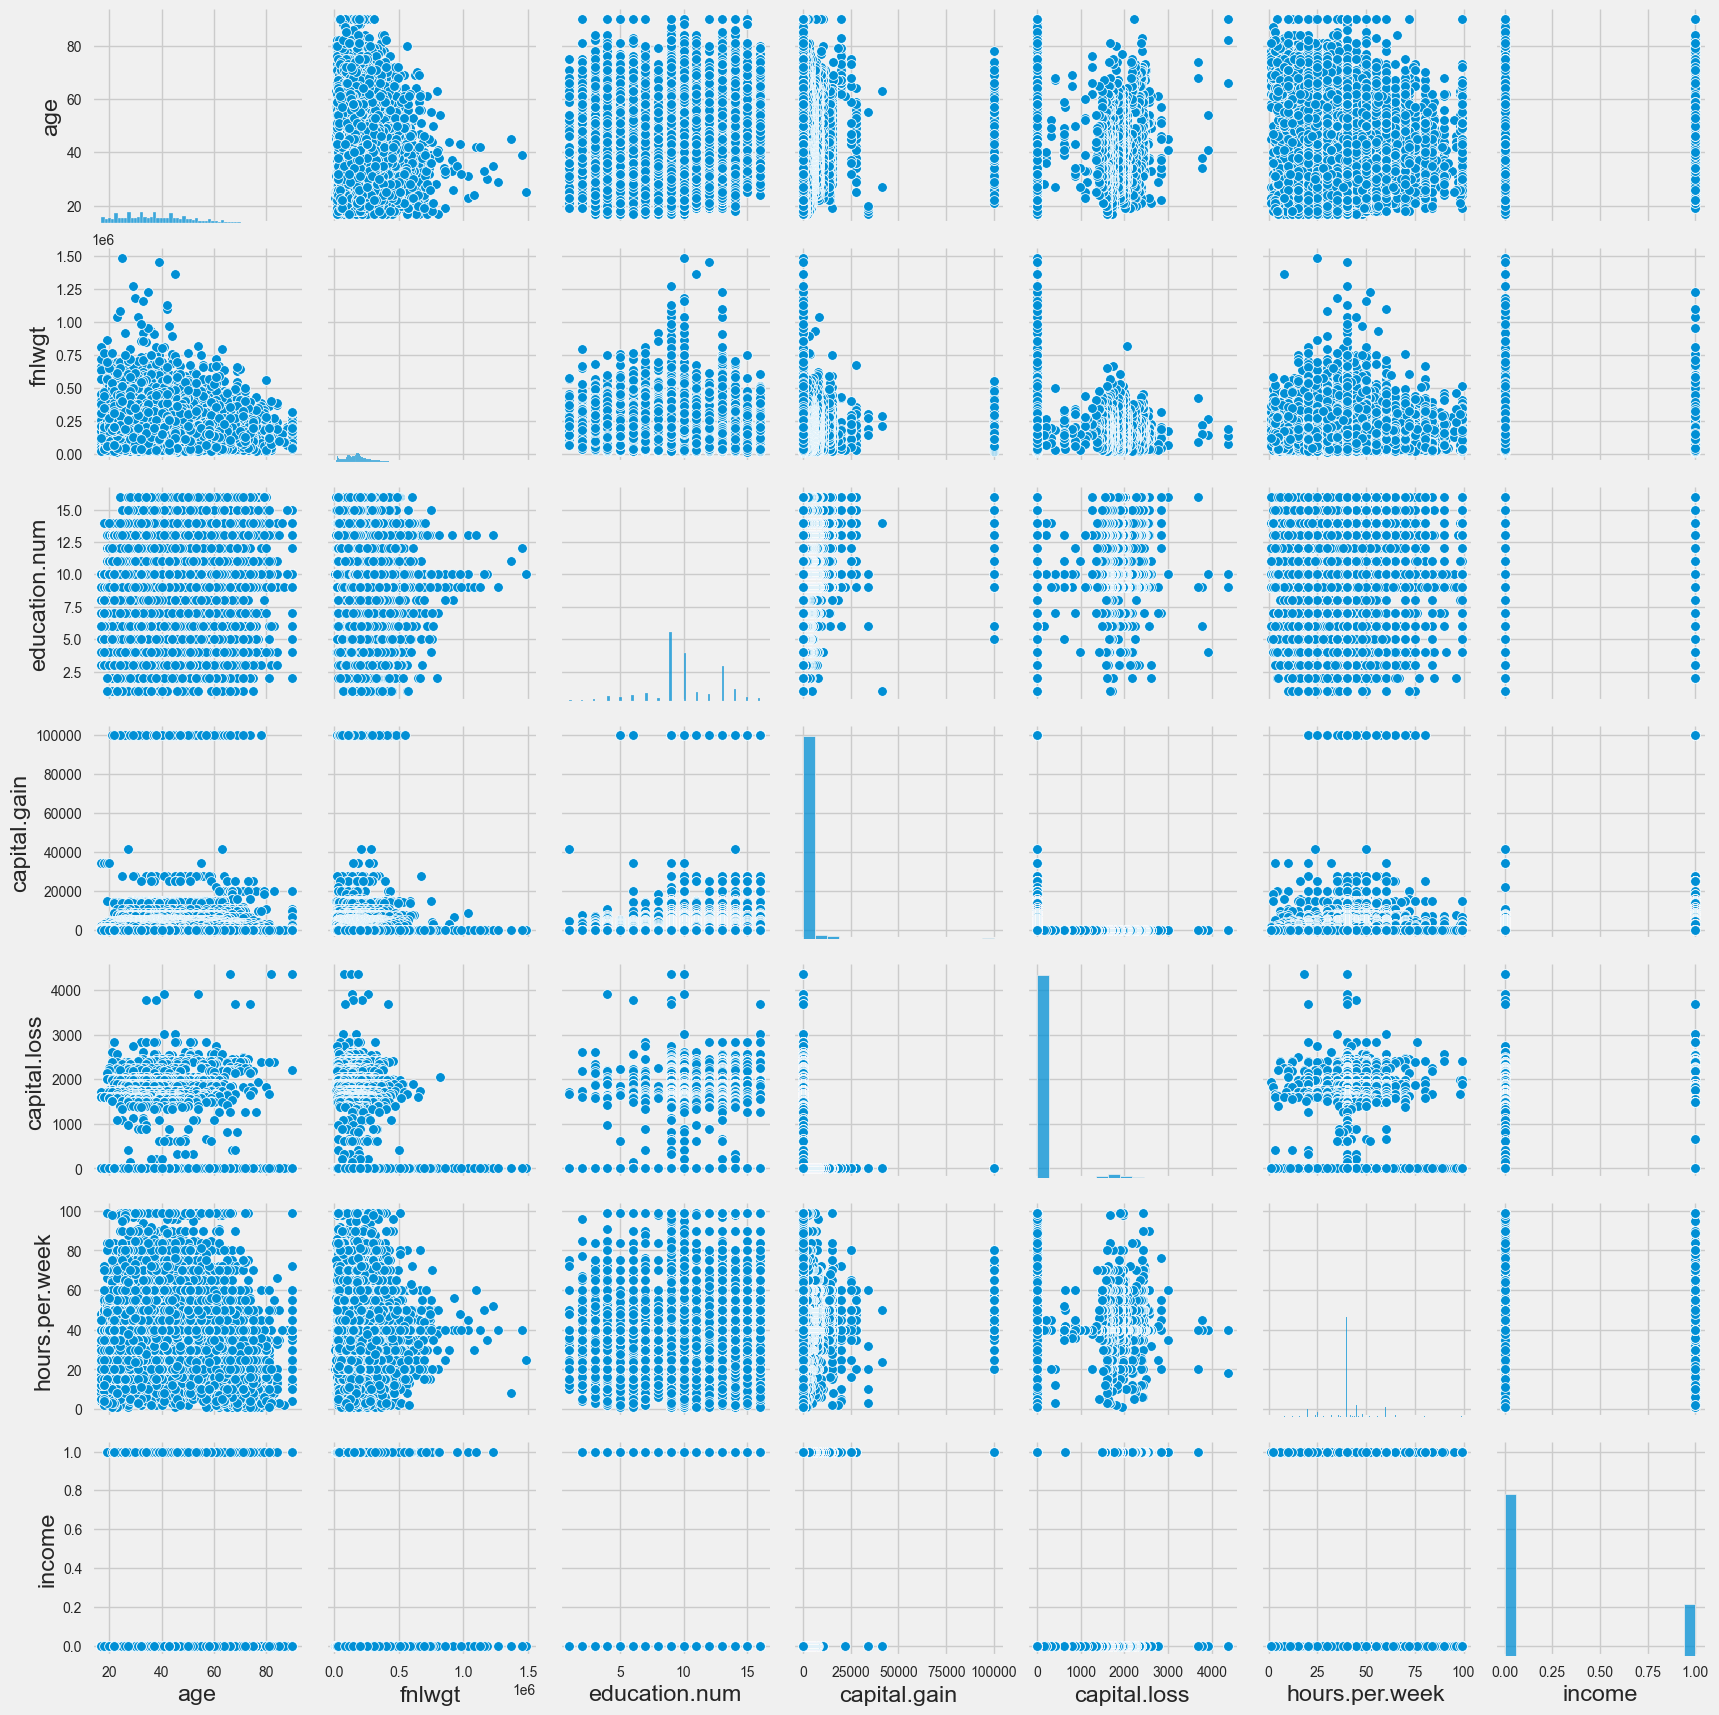

In [34]:
sns.pairplot(dataset)
plt.savefig('multi1.png')
plt.show()

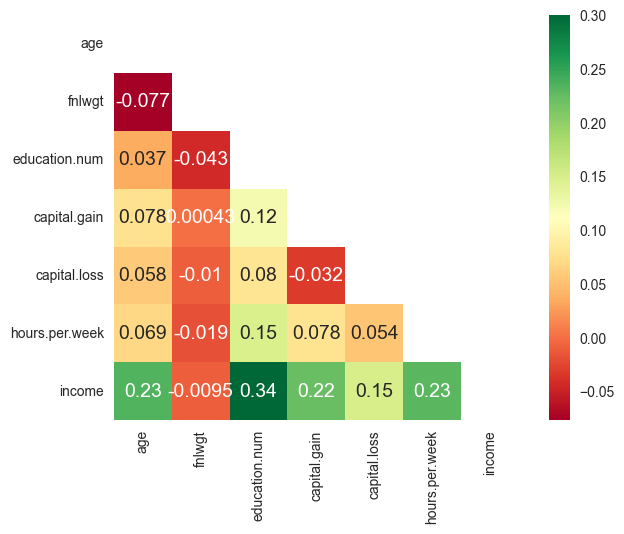

In [36]:
# FIXED: Explicitly set numeric_only=True to handle text columns safely
corr = dataset.corr(numeric_only=True)

mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

with sns.axes_style("white"):
    f, ax = plt.subplots(figsize=(7, 5))
    ax = sns.heatmap(corr, mask=mask, vmax=.3, square=True,
                     annot=True, cmap='RdYlGn')

plt.savefig('multi2.png')
plt.show()

In [37]:
dataset = dataset.replace('?', np.nan)

In [38]:
# Checking null values
round((dataset.isnull().sum() / dataset.shape[0]) * 100, 2).astype(str) + ' %'

age                0.0 %
workclass         5.64 %
fnlwgt             0.0 %
education          0.0 %
education.num      0.0 %
marital.status     0.0 %
occupation        5.66 %
relationship       0.0 %
race               0.0 %
sex                0.0 %
capital.gain       0.0 %
capital.loss       0.0 %
hours.per.week     0.0 %
native.country    1.79 %
income             0.0 %
dtype: object

In [46]:
columns_with_nan = ['workclass', 'occupation', 'native.country']

In [47]:
for col in columns_with_nan:
    dataset[col].fillna(dataset[col].mode()[0], inplace=True)

In [48]:
X = dataset.drop('income', axis=1)
Y = dataset['income']

In [49]:
for col in dataset.columns:
    if dataset[col].dtypes == 'object':
        encoder = LabelEncoder()
        dataset[col] = encoder.fit_transform(dataset[col])

In [50]:
selector = ExtraTreesClassifier(random_state=42)
selector.fit(X, Y)

ExtraTreesClassifier(random_state=42)

In [51]:
feature_imp = selector.feature_importances_

In [52]:
for index, val in enumerate(feature_imp):
    print(index, round((val * 100), 2))

0 15.59
1 4.13
2 16.71
3 3.87
4 8.66
5 8.04
6 7.27
7 8.62
8 1.47
9 2.84
10 8.83
11 2.81
12 9.64
13 1.53


In [53]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  int64
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  int64
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  int64
 6   occupation      32561 non-null  int64
 7   relationship    32561 non-null  int64
 8   race            32561 non-null  int64
 9   sex             32561 non-null  int64
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  int64
dtypes: int64(14)
memory usage: 3.5 MB


In [54]:
X = X.drop(['workclass', 'education', 'race', 'sex',
            'capital.loss', 'native.country'], axis=1)

In [55]:
for col in X.columns:
    scaler = StandardScaler()
    X[col] = scaler.fit_transform(X[col].values.reshape(-1, 1))

In [56]:
round(Y.value_counts(normalize=True) * 100, 2).astype('str') + ' %'

income
0    75.92 %
1    24.08 %
Name: proportion, dtype: object

In [57]:
ros = RandomOverSampler(random_state=42)
ros.fit(X, Y)
X_resampled, Y_resampled = ros.fit_resample(X, Y)

In [58]:
round(Y_resampled.value_counts(normalize=True) * 100, 2).astype('str') + ' %'

income
0    50.0 %
1    50.0 %
Name: proportion, dtype: object

In [59]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_resampled, Y_resampled, test_size=0.2, random_state=42)

In [60]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (39552, 8)
X_test shape: (9888, 8)
Y_train shape: (39552,)
Y_test shape: (9888,)


In [61]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=42)

In [62]:
log_reg.fit(X_train, Y_train)

LogisticRegression(random_state=42)

In [63]:
Y_pred_log_reg = log_reg.predict(X_test)

In [64]:
from sklearn.tree import DecisionTreeClassifier
dec_tree = DecisionTreeClassifier(random_state=42)

In [65]:
dec_tree.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=42)

In [66]:
Y_pred_dec_tree = dec_tree.predict(X_test)

In [67]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [68]:
knn.fit(X_train, Y_train)

KNeighborsClassifier()

In [69]:
Y_pred_knn = knn.predict(X_test)

In [70]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

In [71]:
nb.fit(X_train, Y_train)

GaussianNB()

In [72]:
Y_pred_nb = nb.predict(X_test)

In [73]:
from sklearn.ensemble import RandomForestClassifier
ran_for = RandomForestClassifier(random_state=42)

In [74]:
ran_for.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [75]:
Y_pred_ran_for = ran_for.predict(X_test)

In [76]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, matthews_corrcoef

In [85]:
print('Logistic Regression:')
Y_prob_log_reg = log_reg.predict_proba(X_test)[:, 1]
Y_pred_binary_log_reg = (Y_prob_log_reg >= 0.5).astype(int)
print('Accuracy score:', round(accuracy_score(Y_test, Y_pred_log_reg) * 100, 2))
print('F1 score:', round(f1_score(Y_test, Y_pred_log_reg) * 100, 2))
print('Precision score:', round(precision_score(Y_test, Y_pred_log_reg) * 100, 2))
print('Recall score:', round(recall_score(Y_test, Y_pred_log_reg) * 100, 2))
print('AUC score:', round(roc_auc_score(Y_test, Y_prob_log_reg) * 100, 2))
print('MCC score:', round(matthews_corrcoef(Y_test, Y_pred_binary_log_reg) * 100, 2))

Logistic Regression:
Accuracy score: 75.25
F1 score: 75.08
Precision score: 75.44
Recall score: 74.72
AUC score: 83.81
MCC score: 50.51


In [86]:
print('Decision Tree Classifier:')
Y_prob_dec_tree = dec_tree.predict_proba(X_test)[:, 1]
Y_pred_binary_dec_tree = (Y_prob_dec_tree >= 0.5).astype(int)
print('Accuracy score:', round(accuracy_score(Y_test, Y_pred_dec_tree) * 100, 2))
print('F1 score:', round(f1_score(Y_test, Y_pred_dec_tree) * 100, 2))
print('Precision score:', round(precision_score(Y_test, Y_pred_dec_tree) * 100, 2))
print('Recall score:', round(recall_score(Y_test, Y_pred_dec_tree) * 100, 2))
print('AUC score:', round(roc_auc_score(Y_test, Y_prob_dec_tree) * 100, 2))
print('MCC score:', round(matthews_corrcoef(Y_test, Y_pred_binary_dec_tree) * 100, 2))

Decision Tree Classifier:
Accuracy score: 91.61
F1 score: 92.01
Precision score: 87.57
Recall score: 96.94
AUC score: 91.62
MCC score: 83.69


In [87]:
print('KNN Classifier:')
Y_prob_knn = knn.predict_proba(X_test)[:, 1]
Y_pred_binary_knn = (Y_prob_knn >= 0.5).astype(int)
print('Accuracy score:', round(accuracy_score(Y_test, Y_pred_knn) * 100, 2))
print('F1 score:', round(f1_score(Y_test, Y_pred_knn) * 100, 2))
print('Precision score:', round(precision_score(Y_test, Y_pred_knn) * 100, 2))
print('Recall score:', round(recall_score(Y_test, Y_pred_knn) * 100, 2))
print('AUC score:', round(roc_auc_score(Y_test, Y_prob_knn) * 100, 2))
print('MCC score:', round(matthews_corrcoef(Y_test, Y_pred_binary_knn) * 100, 2))

KNN Classifier:
Accuracy score: 83.42
F1 score: 84.43
Precision score: 79.43
Recall score: 90.11
AUC score: 90.39
MCC score: 67.47


In [89]:
print('Naive Bayes Classifier:')
Y_prob_nb = nb.predict_proba(X_test)[:, 1]
Y_pred_binary_nb = (Y_prob_nb >= 0.5).astype(int)
print('Accuracy score:', round(accuracy_score(Y_test, Y_pred_nb) * 100, 2))
print('F1 score:', round(f1_score(Y_test, Y_pred_nb) * 100, 2))
print('Precision score:', round(precision_score(Y_test, Y_pred_nb) * 100, 2))
print('Recall score:', round(recall_score(Y_test, Y_pred_nb) * 100, 2))
print('AUC score:', round(roc_auc_score(Y_test, Y_prob_nb) * 100, 2))
print('MCC score:', round(matthews_corrcoef(Y_test, Y_pred_nb) * 100, 2))

Naive Bayes Classifier:
Accuracy score: 64.68
F1 score: 48.42
Precision score: 89.22
Recall score: 33.23
AUC score: 86.82
MCC score: 37.58


In [88]:
print('Random Forest Classifier:')
Y_prob_ran_for = ran_for.predict_proba(X_test)[:, 1]
Y_pred_binary_ran_for = (Y_prob_ran_for >= 0.5).astype(int)
print('Accuracy score:', round(accuracy_score(Y_test, Y_pred_ran_for) * 100, 2))
print('F1 score:', round(f1_score(Y_test, Y_pred_ran_for) * 100, 2))
print('Precision score:', round(precision_score(Y_test, Y_pred_ran_for) * 100, 2))
print('Recall score:', round(recall_score(Y_test, Y_pred_ran_for) * 100, 2))
print('AUC score:', round(roc_auc_score(Y_test, Y_prob_ran_for) * 100, 2))
print('MCC score:', round(matthews_corrcoef(Y_test, Y_pred_binary_ran_for) * 100, 2))

Random Forest Classifier:
Accuracy score: 92.6
F1 score: 92.93
Precision score: 88.7
Recall score: 97.59
AUC score: 98.3
MCC score: 85.47


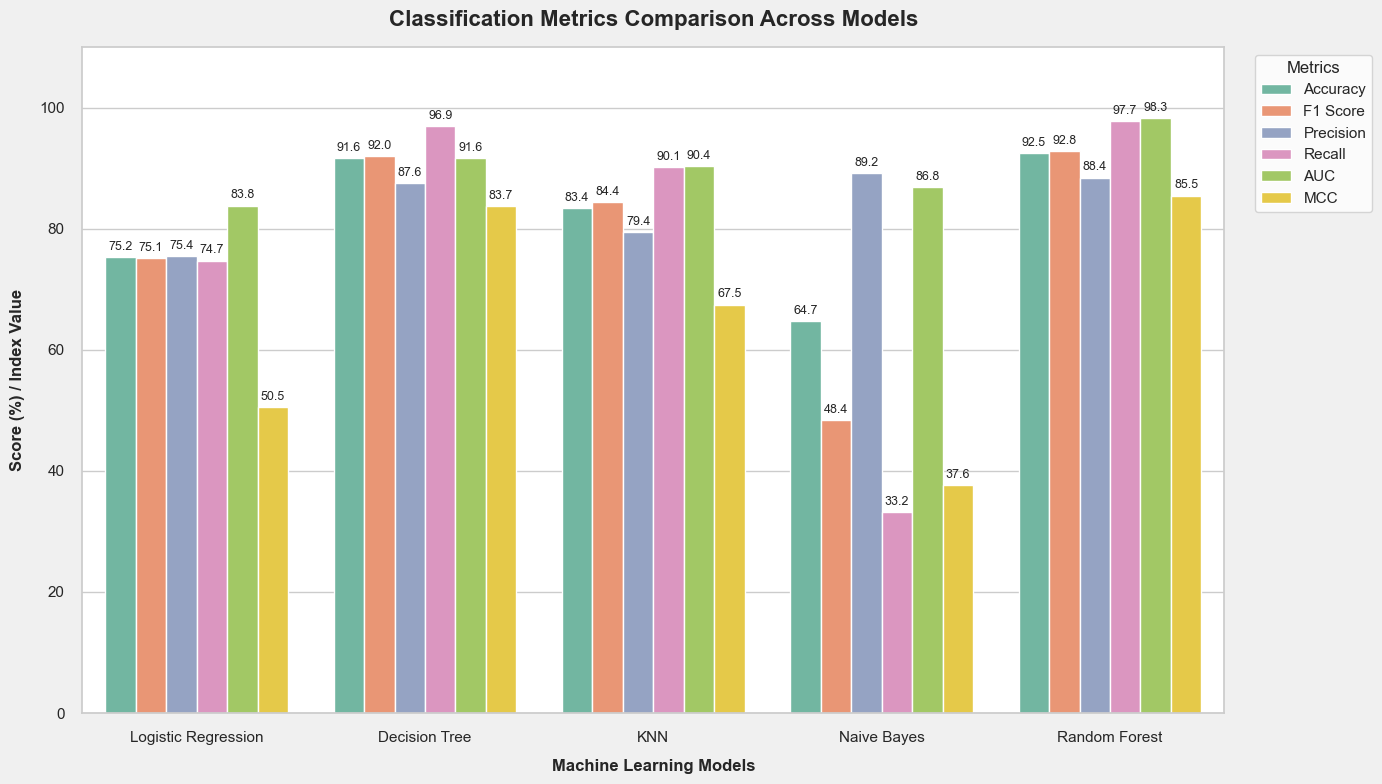

In [91]:
# 1. Define predictions safely for ALL models
# Logistic Regression
Y_prob_log_reg = log_reg.predict_proba(X_test)[:, 1]
Y_pred_log_reg = (Y_prob_log_reg >= 0.5).astype(int)

# Decision Tree
Y_prob_dec_tree = dec_tree.predict_proba(X_test)[:, 1]
Y_pred_dec_tree = (Y_prob_dec_tree >= 0.5).astype(int)

# KNN
Y_prob_knn = knn.predict_proba(X_test)[:, 1]
Y_pred_knn = (Y_prob_knn >= 0.5).astype(int)

# Naive Bayes
Y_prob_nb = nb.predict_proba(X_test)[:, 1]
Y_pred_nb = (Y_prob_nb >= 0.5).astype(int)

# Random Forest
Y_prob_ran_for = ran_for.predict_proba(X_test)[:, 1]
Y_pred_ran_for = (Y_prob_ran_for >= 0.5).astype(int)


# 2. Directly structure your results dictionary
results = {
    'Logistic Regression': {
        'Accuracy': round(accuracy_score(Y_test, Y_pred_log_reg) * 100, 2),
        'F1 Score': round(f1_score(Y_test, Y_pred_log_reg) * 100, 2),
        'Precision': round(precision_score(Y_test, Y_pred_log_reg) * 100, 2),
        'Recall': round(recall_score(Y_test, Y_pred_log_reg) * 100, 2),
        'AUC': round(roc_auc_score(Y_test, Y_prob_log_reg) * 100, 2),
        'MCC': round(matthews_corrcoef(Y_test, Y_pred_log_reg) * 100, 2)
    },
    'Decision Tree': {
        'Accuracy': round(accuracy_score(Y_test, Y_pred_dec_tree) * 100, 2),
        'F1 Score': round(f1_score(Y_test, Y_pred_dec_tree) * 100, 2),
        'Precision': round(precision_score(Y_test, Y_pred_dec_tree) * 100, 2),
        'Recall': round(recall_score(Y_test, Y_pred_dec_tree) * 100, 2),
        'AUC': round(roc_auc_score(Y_test, Y_prob_dec_tree) * 100, 2),
        'MCC': round(matthews_corrcoef(Y_test, Y_pred_dec_tree) * 100, 2)
    },
    'KNN': {
        'Accuracy': round(accuracy_score(Y_test, Y_pred_knn) * 100, 2),
        'F1 Score': round(f1_score(Y_test, Y_pred_knn) * 100, 2),
        'Precision': round(precision_score(Y_test, Y_pred_knn) * 100, 2),
        'Recall': round(recall_score(Y_test, Y_pred_knn) * 100, 2),
        'AUC': round(roc_auc_score(Y_test, Y_prob_knn) * 100, 2),
        'MCC': round(matthews_corrcoef(Y_test, Y_pred_knn) * 100, 2)
    },
    'Naive Bayes': {
        'Accuracy': round(accuracy_score(Y_test, Y_pred_nb) * 100, 2),
        'F1 Score': round(f1_score(Y_test, Y_pred_nb) * 100, 2),
        'Precision': round(precision_score(Y_test, Y_pred_nb) * 100, 2),
        'Recall': round(recall_score(Y_test, Y_pred_nb) * 100, 2),
        'AUC': round(roc_auc_score(Y_test, Y_prob_nb) * 100, 2),
        'MCC': round(matthews_corrcoef(Y_test, Y_pred_nb) * 100, 2)
    },
    'Random Forest': {
        'Accuracy': round(accuracy_score(Y_test, Y_pred_ran_for) * 100, 2),
        'F1 Score': round(f1_score(Y_test, Y_pred_ran_for) * 100, 2),
        'Precision': round(precision_score(Y_test, Y_pred_ran_for) * 100, 2),
        'Recall': round(recall_score(Y_test, Y_pred_ran_for) * 100, 2),
        'AUC': round(roc_auc_score(Y_test, Y_prob_ran_for) * 100, 2),
        'MCC': round(matthews_corrcoef(Y_test, Y_pred_ran_for) * 100, 2)
    }
}

# 3. Create DataFrame and reshape for Seaborn plotting
df_results = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
df_melted = pd.melt(df_results, id_vars='Model', var_name='Metric', value_name='Score')

# 4. Generate the Grouped Bar Chart
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='Set2')

plt.title('Classification Metrics Comparison Across Models', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Machine Learning Models', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Score (%) / Index Value', fontsize=12, fontweight='bold', labelpad=10)
plt.ylim(0, 110)
plt.legend(title='Metrics', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

# Add numerical values above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

In [92]:
from sklearn.model_selection import RandomizedSearchCV

In [93]:
n_estimators = [int(x) for x in np.linspace(start=40, stop=150, num=15)]
max_depth = [int(x) for x in np.linspace(40, 150, num=15)]

In [94]:
param_dist = {
    'n_estimators': n_estimators,
    'max_depth': max_depth,
}

In [95]:
rf_tuned = RandomForestClassifier(random_state=42)

In [96]:
rf_cv = RandomizedSearchCV(
    estimator=rf_tuned, param_distributions=param_dist, cv=5, random_state=42)

In [97]:
rf_cv.fit(X_train, Y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'max_depth': [40, 47, 55, 63, 71, 79,
                                                      87, 95, 102, 110, 118,
                                                      126, 134, 142, 150],
                                        'n_estimators': [40, 47, 55, 63, 71, 79,
                                                         87, 95, 102, 110, 118,
                                                         126, 134, 142, 150]},
                   random_state=42)

In [98]:
rf_cv.best_score_
rf_cv.best_params_

{'n_estimators': 40, 'max_depth': 102}

In [99]:
rf_best = RandomForestClassifier(
    max_depth=102, n_estimators=40, random_state=42)

In [100]:
rf_best.fit(X_train, Y_train)

RandomForestClassifier(max_depth=102, n_estimators=40, random_state=42)

In [101]:
Y_pred_rf_best = rf_best.predict(X_test)

In [104]:
print('Random Forest Classifier Hypertuned:')
Y_prob_rf_best = rf_cv.predict_proba(X_test)[:, 1]
Y_pred_binary_rf_cv = (Y_prob_ran_for >= 0.5).astype(int)
print('Accuracy score:', round(accuracy_score(Y_test, Y_pred_rf_best) * 100, 2))
print('F1 score:', round(f1_score(Y_test, Y_pred_rf_best) * 100, 2))
print('Precision score:', round(precision_score(Y_test, Y_pred_rf_best) * 100, 2))
print('Recall score:', round(recall_score(Y_test, Y_pred_rf_best) * 100, 2))
print('AUC score:', round(roc_auc_score(Y_test, Y_prob_rf_best) * 100, 2))
print('MCC score:', round(matthews_corrcoef(Y_test, Y_pred_rf_best) * 100, 2))

Random Forest Classifier Hypertuned:
Accuracy score: 92.77
F1 score: 93.08
Precision score: 89.03
Recall score: 97.53
AUC score: 98.13
MCC score: 85.93


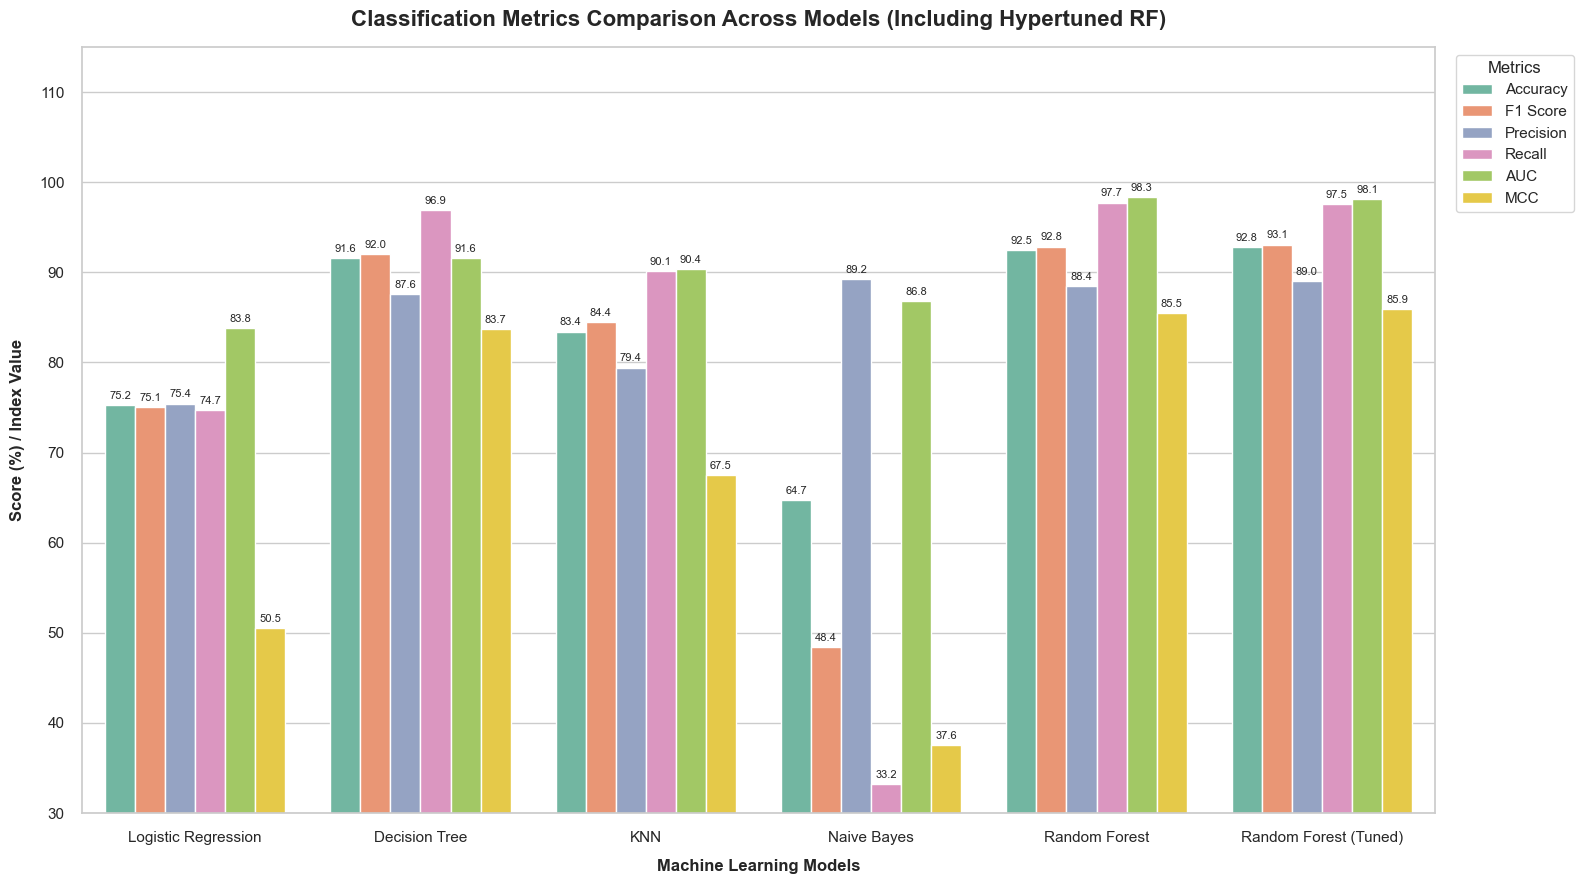

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, matthews_corrcoef

# 1. Define predictions safely for ALL models
# Logistic Regression
Y_prob_log_reg = log_reg.predict_proba(X_test)[:, 1]
Y_pred_log_reg = (Y_prob_log_reg >= 0.5).astype(int)

# Decision Tree
Y_prob_dec_tree = dec_tree.predict_proba(X_test)[:, 1]
Y_pred_dec_tree = (Y_prob_dec_tree >= 0.5).astype(int)

# KNN
Y_prob_knn = knn.predict_proba(X_test)[:, 1]
Y_pred_knn = (Y_prob_knn >= 0.5).astype(int)

# Naive Bayes
Y_prob_nb = nb.predict_proba(X_test)[:, 1]
Y_pred_nb = (Y_prob_nb >= 0.5).astype(int)

# Random Forest
Y_prob_ran_for = ran_for.predict_proba(X_test)[:, 1]
Y_pred_ran_for = (Y_prob_ran_for >= 0.5).astype(int)

# Random Forest Hypertuned (Variables corrected to avoid mix-ups)
Y_prob_rf_cv = rf_cv.predict_proba(X_test)[:, 1]
Y_pred_rf_cv = (Y_prob_rf_cv >= 0.5).astype(int)


# 2. Directly structure your results dictionary
results = {
    'Logistic Regression': {
        'Accuracy': round(accuracy_score(Y_test, Y_pred_log_reg) * 100, 2),
        'F1 Score': round(f1_score(Y_test, Y_pred_log_reg) * 100, 2),
        'Precision': round(precision_score(Y_test, Y_pred_log_reg) * 100, 2),
        'Recall': round(recall_score(Y_test, Y_pred_log_reg) * 100, 2),
        'AUC': round(roc_auc_score(Y_test, Y_prob_log_reg) * 100, 2),
        'MCC': round(matthews_corrcoef(Y_test, Y_pred_log_reg) * 100, 2)
    },
    'Decision Tree': {
        'Accuracy': round(accuracy_score(Y_test, Y_pred_dec_tree) * 100, 2),
        'F1 Score': round(f1_score(Y_test, Y_pred_dec_tree) * 100, 2),
        'Precision': round(precision_score(Y_test, Y_pred_dec_tree) * 100, 2),
        'Recall': round(recall_score(Y_test, Y_pred_dec_tree) * 100, 2),
        'AUC': round(roc_auc_score(Y_test, Y_prob_dec_tree) * 100, 2),
        'MCC': round(matthews_corrcoef(Y_test, Y_pred_dec_tree) * 100, 2)
    },
    'KNN': {
        'Accuracy': round(accuracy_score(Y_test, Y_pred_knn) * 100, 2),
        'F1 Score': round(f1_score(Y_test, Y_pred_knn) * 100, 2),
        'Precision': round(precision_score(Y_test, Y_pred_knn) * 100, 2),
        'Recall': round(recall_score(Y_test, Y_pred_knn) * 100, 2),
        'AUC': round(roc_auc_score(Y_test, Y_prob_knn) * 100, 2),
        'MCC': round(matthews_corrcoef(Y_test, Y_pred_knn) * 100, 2)
    },
    'Naive Bayes': {
        'Accuracy': round(accuracy_score(Y_test, Y_pred_nb) * 100, 2),
        'F1 Score': round(f1_score(Y_test, Y_pred_nb) * 100, 2),
        'Precision': round(precision_score(Y_test, Y_pred_nb) * 100, 2),
        'Recall': round(recall_score(Y_test, Y_pred_nb) * 100, 2),
        'AUC': round(roc_auc_score(Y_test, Y_prob_nb) * 100, 2),
        'MCC': round(matthews_corrcoef(Y_test, Y_pred_nb) * 100, 2)
    },
    'Random Forest': {
        'Accuracy': round(accuracy_score(Y_test, Y_pred_ran_for) * 100, 2),
        'F1 Score': round(f1_score(Y_test, Y_pred_ran_for) * 100, 2),
        'Precision': round(precision_score(Y_test, Y_pred_ran_for) * 100, 2),
        'Recall': round(recall_score(Y_test, Y_pred_ran_for) * 100, 2),
        'AUC': round(roc_auc_score(Y_test, Y_prob_ran_for) * 100, 2),
        'MCC': round(matthews_corrcoef(Y_test, Y_pred_ran_for) * 100, 2)
    },
    'Random Forest (Tuned)': {
        'Accuracy': round(accuracy_score(Y_test, Y_pred_rf_best) * 100, 2),
        'F1 Score': round(f1_score(Y_test, Y_pred_rf_best) * 100, 2),
        'Precision': round(precision_score(Y_test, Y_pred_rf_best) * 100, 2),
        'Recall': round(recall_score(Y_test, Y_pred_rf_best) * 100, 2),
        'AUC': round(roc_auc_score(Y_test, Y_prob_rf_best) * 100, 2),
        'MCC': round(matthews_corrcoef(Y_test, Y_pred_rf_best) * 100, 2)
    }
}

# 3. Create DataFrame and reshape for Seaborn plotting
df_results = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
df_melted = pd.melt(df_results, id_vars='Model', var_name='Metric', value_name='Score')

# 4. Generate the Grouped Bar Chart
plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='Set2')

plt.title('Classification Metrics Comparison Across Models (Including Hypertuned RF)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Machine Learning Models', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Score (%) / Index Value', fontsize=12, fontweight='bold', labelpad=10)
plt.ylim(30, 115)  # Adjusted limit for better data labels spacing
plt.legend(title='Metrics', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)

# Add numerical values above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=8)

plt.tight_layout()
plt.show()
